**Libraries**

In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from functools import reduce
from pathlib import Path

import numpy as np
from numpy.typing import NDArray
import pandas as pd
import matplotlib.pyplot as plt

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.mask import codedmask, count
from bloodmoon.mask import variance, snratio

import darksun as ds
from darksun.types import Tag
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.benchmarking import dict2df
from darksun.utils import savefig_to
from darksun.show import DSPlot

**Analysis Methods**

In [2]:
def extract_catalogue_angular_coords(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources angular coords.
    """
    angles_x, angles_y = [], []
    for sourceID in log.log['ID']:
        anglex, angley = (
            ds.source_angular_coords(sourceID, catalogue, sdl, camera)
            if sourceID in catalogue.DLdata['ID']
            else (np.nan, np.nan)
        )
        angles_x.append(anglex)
        angles_y.append(angley)
        
    df = pd.DataFrame(
        {'ID': log.log['ID'], 'angle_x': angles_x, 'angle_y': angles_y}
    )
    return df


def get_angularcoords_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[NDArray, NDArray]:
    """
    Computes the angular coords residues between the IROS
    sources and the catalogue sources in [arcmin].
    """
    angular_coords = extract_catalogue_angular_coords(log, catalogue, sdl, camera)
    angles_x, angles_y = map(
        np.array, (angular_coords['angle_x'], angular_coords['angle_y']),
    )
    res_x, res_y = (
        60 * np.abs(np.array(log.log['angle_x']) - angles_x),
        60 * np.abs(np.array(log.log['angle_y']) - angles_y),
    )
    return res_x, res_y


def extract_catalogue_fluences(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources fluences.
    """
    fluences = []
    for sourceID in log.log['ID']:
        fluence = (
            ds.source_fluence(sourceID, catalogue, sdl, camera, verbose)
            if sourceID in catalogue.DLdata['ID']
            else np.nan
        )
        fluences.append(fluence)
        
    df = pd.DataFrame(
        {'ID': log.log['ID'], 'fluence': fluences}
    )
    return df


def get_fluence_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> NDArray:
    """
    Computes the percentage fluence residues between the IROS
    and the catalogue sources.
    """
    df = extract_catalogue_fluences(log, catalogue, sdl, camera, verbose)
    fluences = np.array(df['fluence'])
    res = np.array(log.log['fluence']) - fluences
    return res * 100 / fluences


def reconstruction_data(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Generates a Dataframe with output data from IROS.
    """
    theta_res_x, theta_res_y = get_angularcoords_residues(
        log, catalogue, sdl, camera,
    )
    fluence_res = get_fluence_residues(
        log, catalogue, sdl, camera, verbose,
    )
    dmap = {
        log.name: {
            'ID': log.log['ID'],
            'Brightest': log.log['id_brightest'],
            'SNR': log.log['snr'],
            'DthetaX [arcmin]': theta_res_x,
            'DthetaY [arcmin]': theta_res_y,
            'Dfluence [%]': fluence_res,
        }
    }
    return dict2df(dmap)

In [ ]:
def build_run_DF(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """Builds the DF for the specified IROS run with the angular coords."""
    angular_coords = extract_catalogue_angular_coords(log, catalogue, sdl, camera)
    cat_theta_x, cat_theta_y = map(
        np.array, (angular_coords['angle_x'], angular_coords['angle_y']),
    )
    res_x, res_y = (
        60 * np.abs(np.array(log.log['angle_x']) - cat_theta_x),
        60 * np.abs(np.array(log.log['angle_y']) - cat_theta_y),
    )
    fluence_res = get_fluence_residues(
        log, catalogue, sdl, camera, False,
    )
    dmap = {
        'ID': log.log['ID'],
        'theta_true_x': cat_theta_x,
        'theta_res_x': res_x,
        'theta_true_y': cat_theta_y,
        'theta_res_y': res_y,
        'fluence_res': fluence_res,
    }
    return pd.DataFrame(dmap)


def extract_data_along_finedir(data: pd.DataFrame) -> pd.DataFrame:
    """Extract angular coords residues along the camera fine direction."""
    cols = ['ID', 'theta_true_x', 'theta_res_x']
    return data[cols]


def extract_data_along_coarsedir(data: pd.DataFrame) -> pd.DataFrame:
    """Extract angular coords residues along the camera coarse direction."""
    cols = ['ID', 'theta_true_y', 'theta_res_y']
    return data[cols]


def merge_runs(
    *args: pd.DataFrame,
    on: str = 'ID',
) -> pd.DataFrame:
    """Merges the DFs of different IROS runs."""
    return reduce(
        lambda left, right: pd.merge(left, right, on=on, how='outer'),
        args,
    )

In [4]:
#from random import sample
#
#SETUP = {'key': 0}
#
#def random_DF(size: int) -> pd.DataFrame:
#    start, stop = 0, 100
#    ids = tuple(
#        f's{idx}' for idx in np.unique(np.random.randint(start, stop, 1000)[:size])
#    )
#    dmap = {
#        'ID': ids,
#        f'A_{SETUP['key']}': np.random.randint(start, stop, size),
#        f'A_{SETUP['key']}': np.random.randint(start, stop, size),
#        f'B_{SETUP['key']}': np.random.randint(start, stop, size),
#    }
#    SETUP['key'] += 1
#    return pd.DataFrame(dmap)
#
#
#dfA, dfB, dfC = random_DF(5), random_DF(6), random_DF(5)
#
#merge_runs(dfA, dfB, dfC), dfA, dfB, dfC

**Mask and Data Specifics**

In [5]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_fmin0.0945_2-50keV_1ks"

ANALYSIS_IDs: tuple[str, ...] = (
    "singleCAM_iros_upx5upy1_newOptimiser",
    "singleCAM_iros_upx5upy1_10um",
    "singleCAM_iros_upx5upy1_2-10keV",
)
#ANALYSIS_IDs: tuple[str, ...] = (
#    "singleCAM_iros_upx5upy1_newOptimiser_smoothing",
#    "singleCAM_iros_upx5upy1_10um_smoothing",
#    "singleCAM_iros_upx5upy1_2-10keV_smoothing",
#)

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 5
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = True

In [ ]:
# save plot and images
SAVE_TO: str | Path = '/home/edoardo/Desktop/residues/baseline'
SAVE_THINGS: bool = False

In [7]:
# load filepaths
mask_path, simul_data, _ = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)

**Load Databases with IROS runs**

In [8]:
basepath: str = (
    '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Outputs/OutGalacticCentre/galctr_rxte-sax_mask_050_1040x17_fmin0.0945_2-50keV_1ks'
)
#basepath: str = '/mnt/d/PhD_AASS/Coding/Images_fits'

path_runs: list[str] = [
    f"{basepath}/{test}/IROS_sources_database_TEST_{test}.fits"
    for test in ANALYSIS_IDs
]

logs_camA, logs_camB = zip(
    *tuple(ds.load_database(path) for path in path_runs)
)

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


**Load WISEMAN data**

In [9]:
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])

# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

**Residues benchmark plots - Camera A**

In [10]:
dfs_camA = tuple(
    map(lambda x: build_run_DF(x, catalogueA, sdlA, wfm), logs_camA)
)

## USING BULK MASK with 1.5 mm cover ##


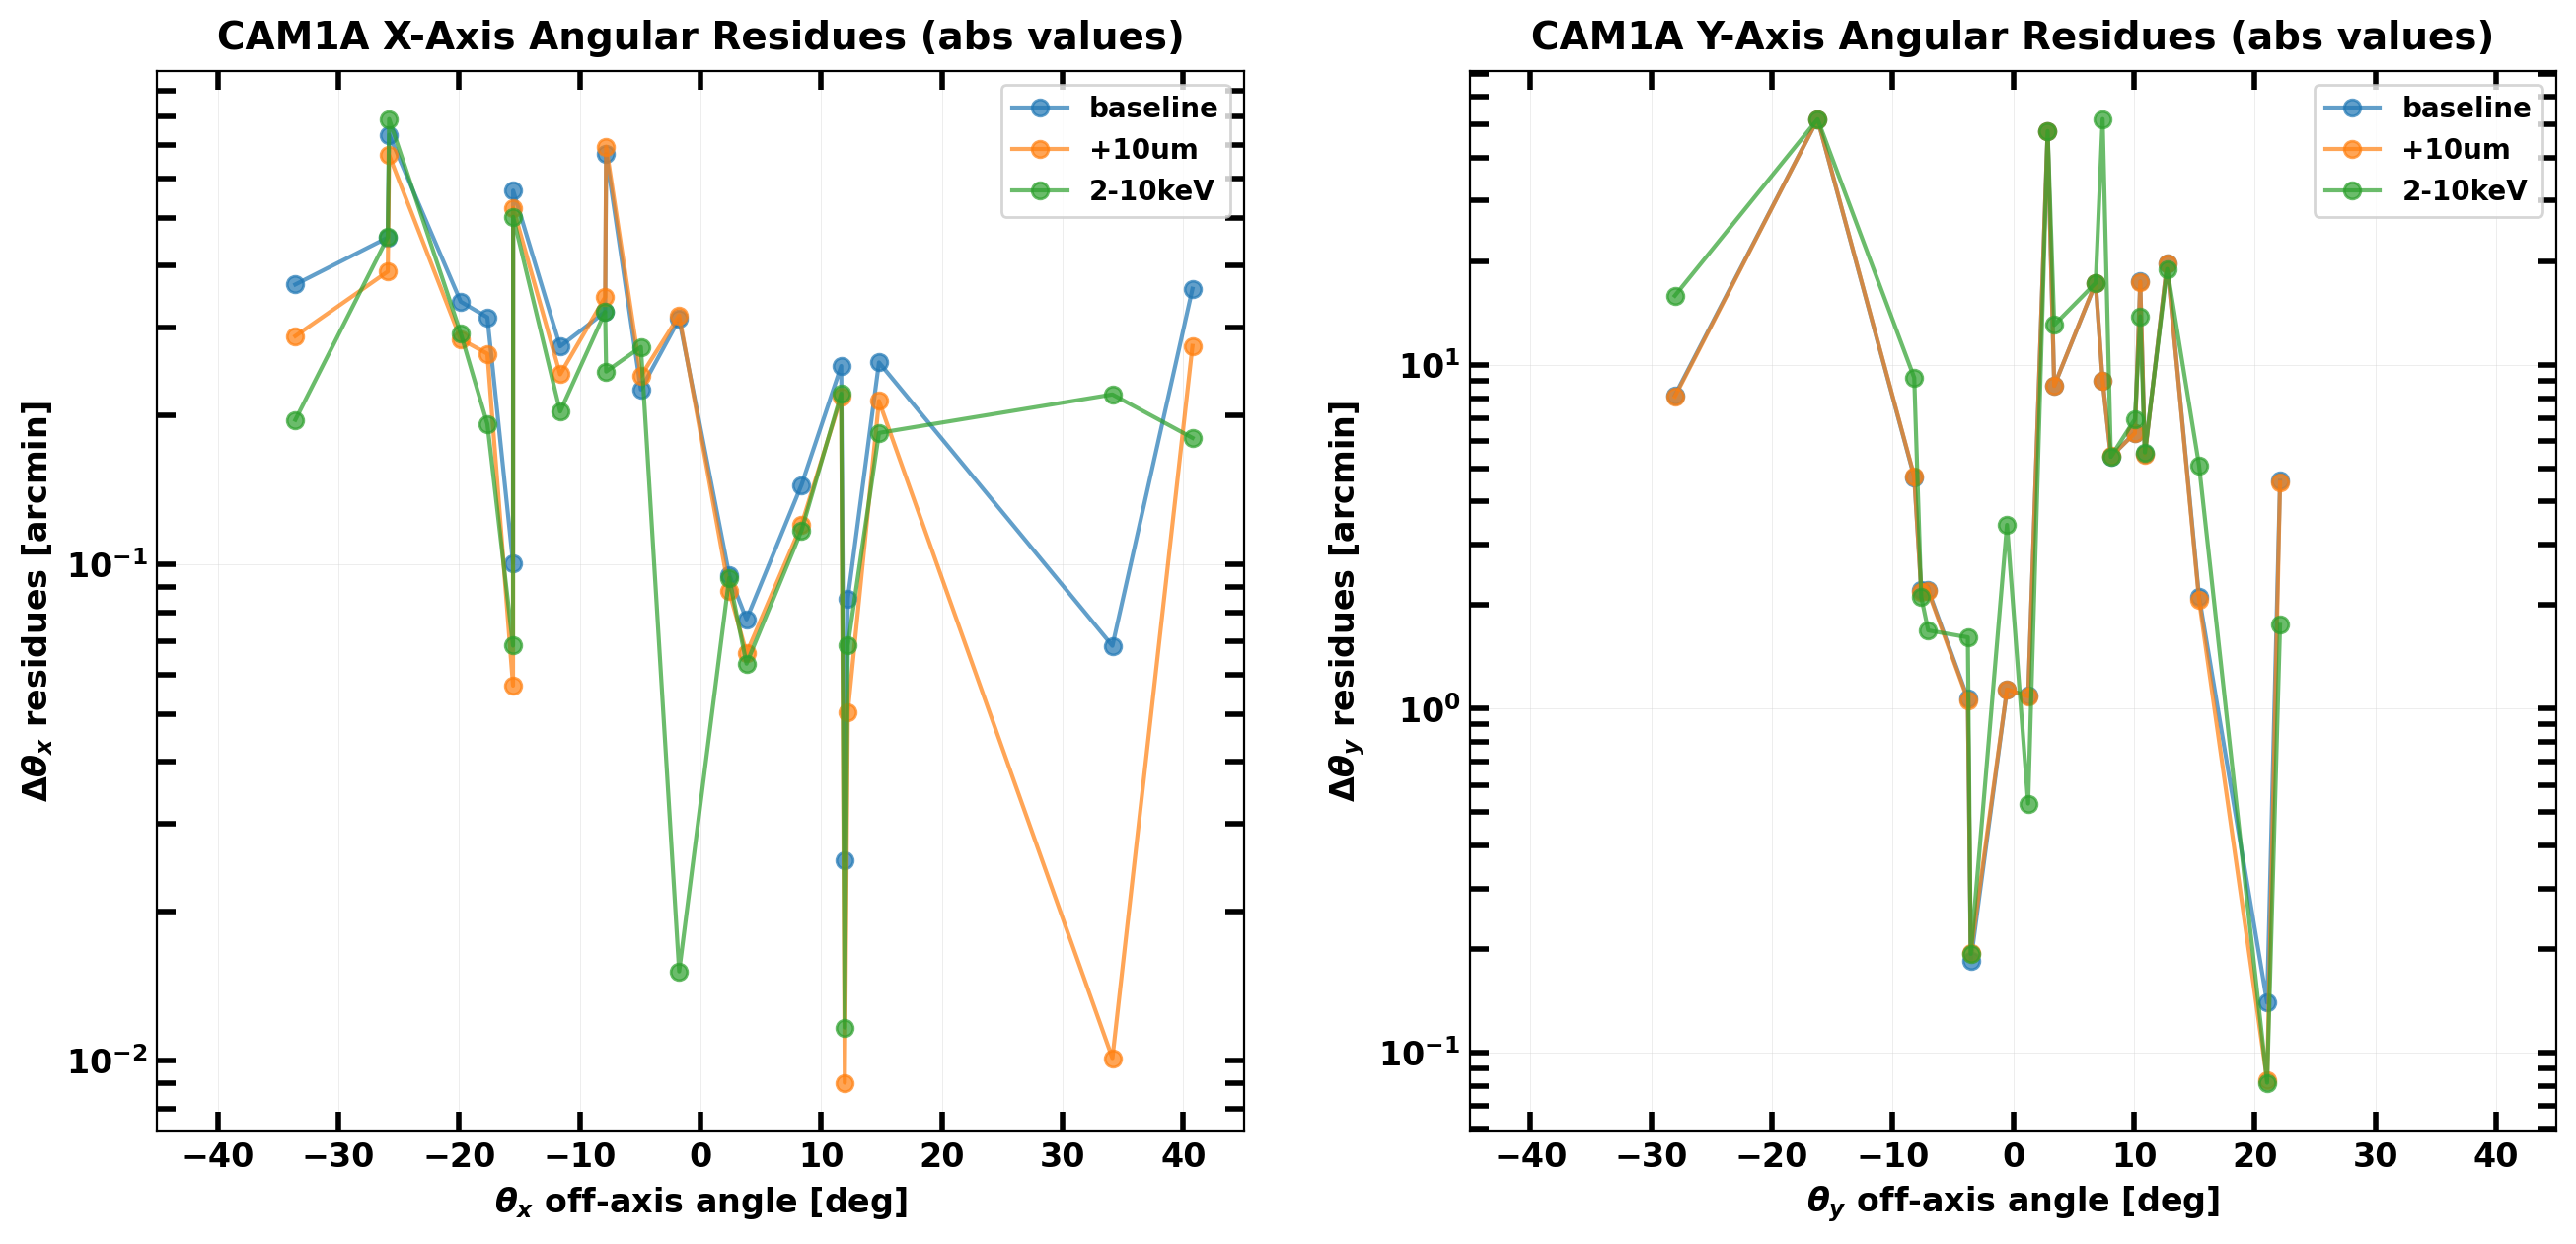

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


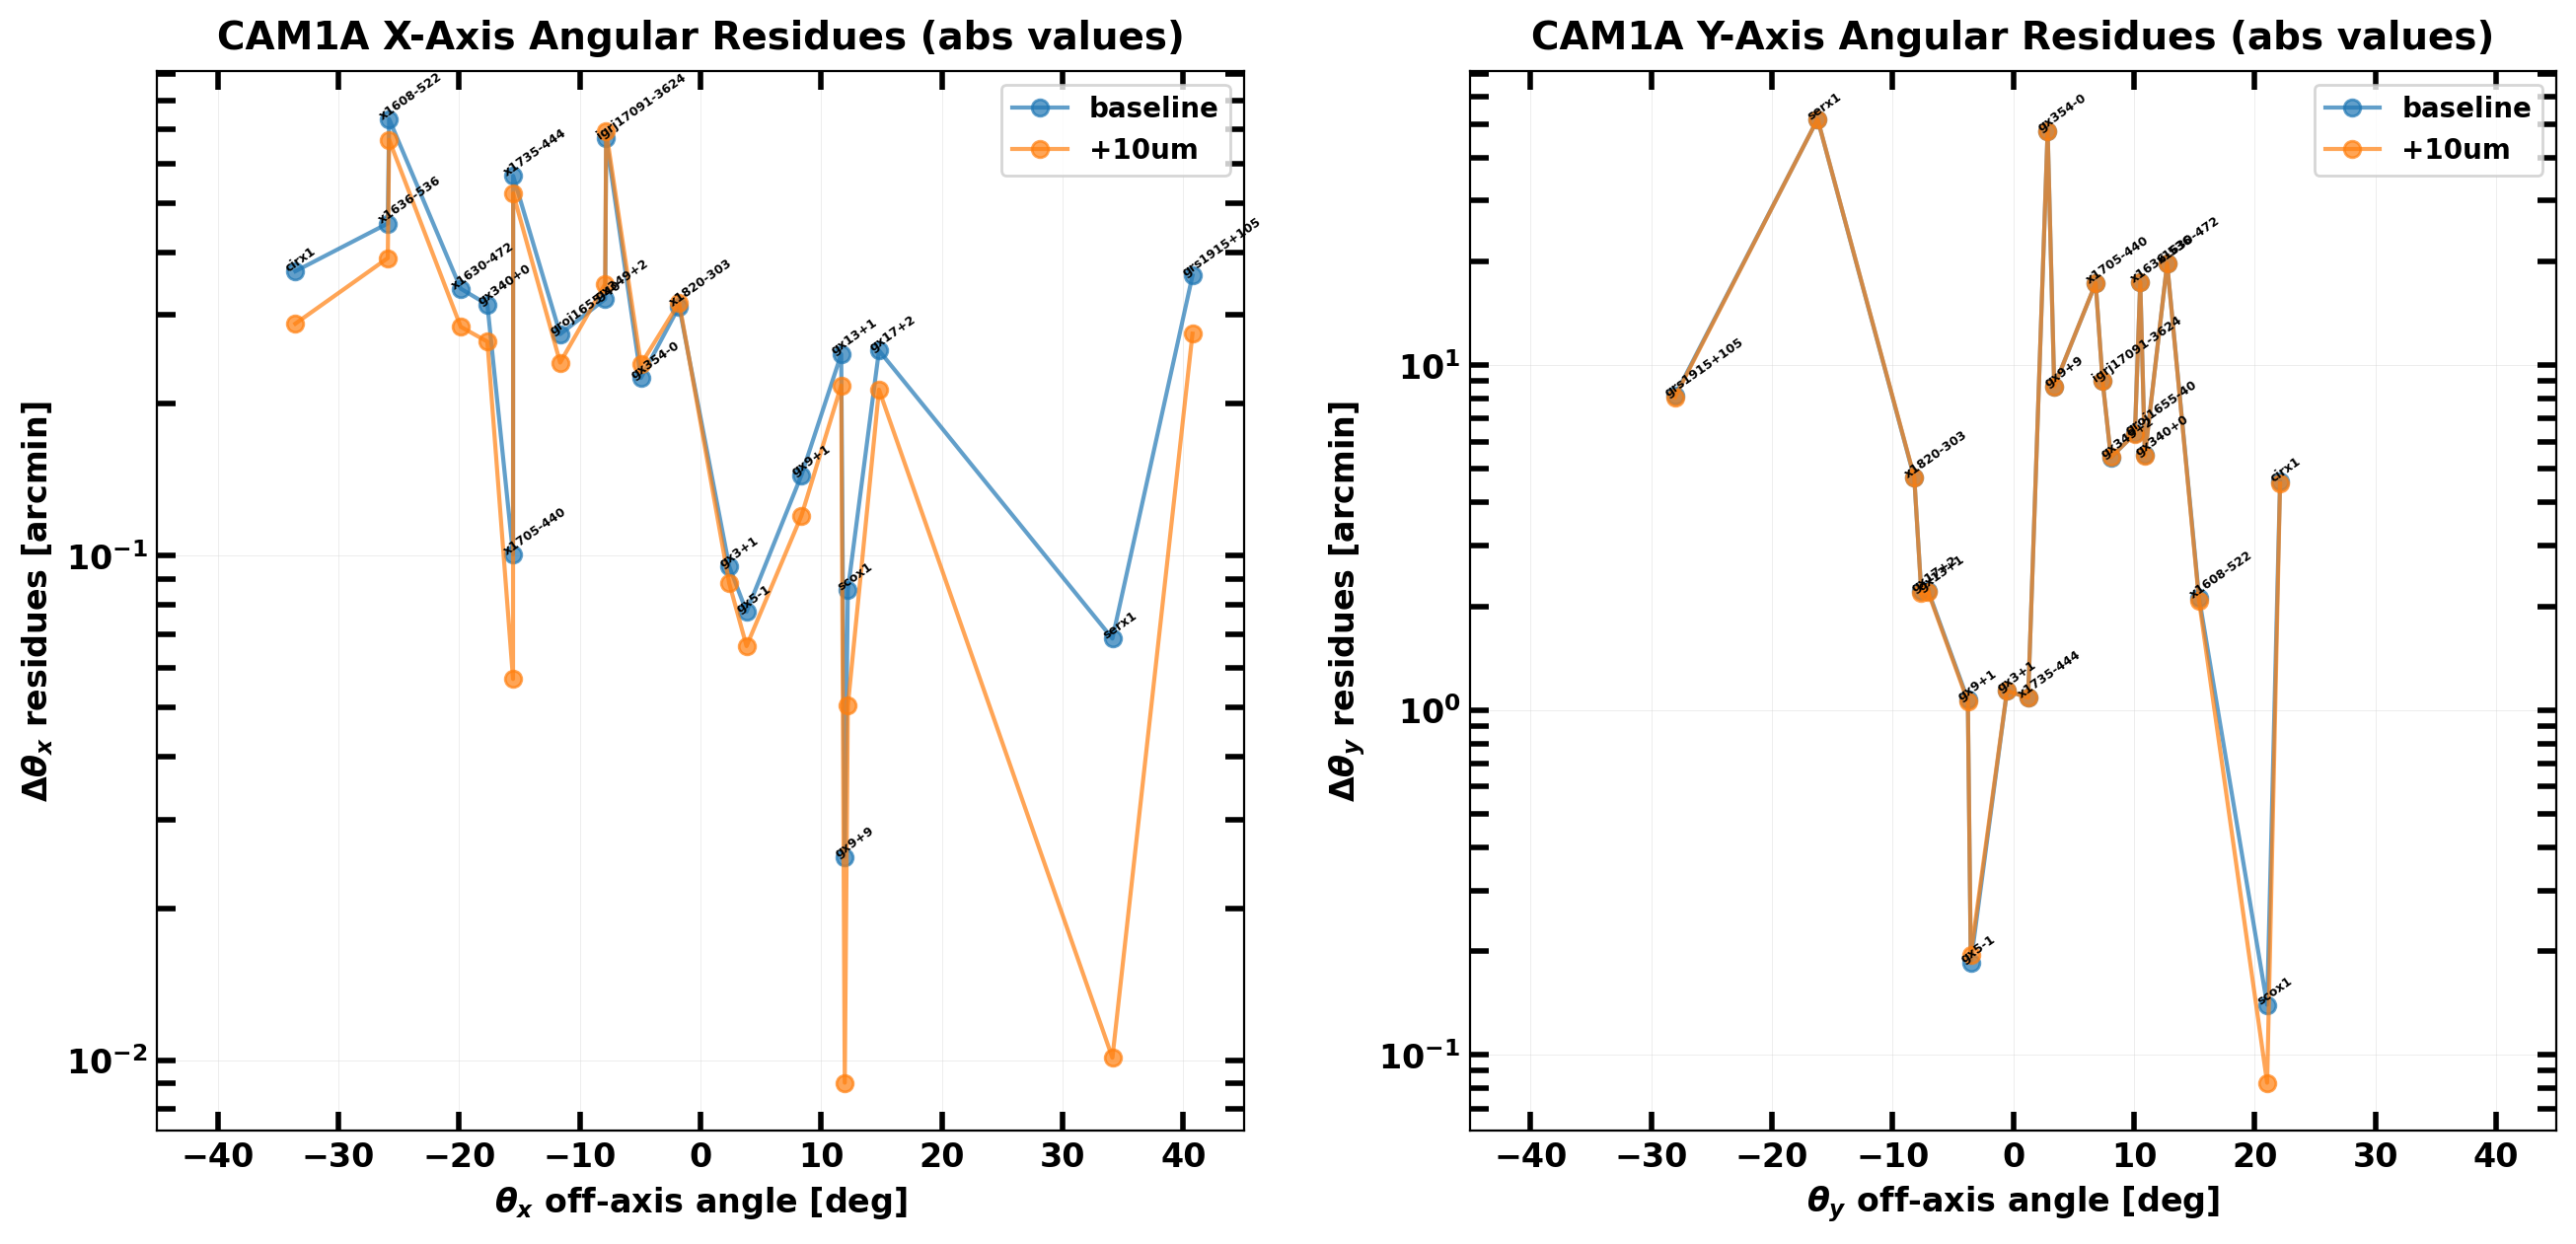

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


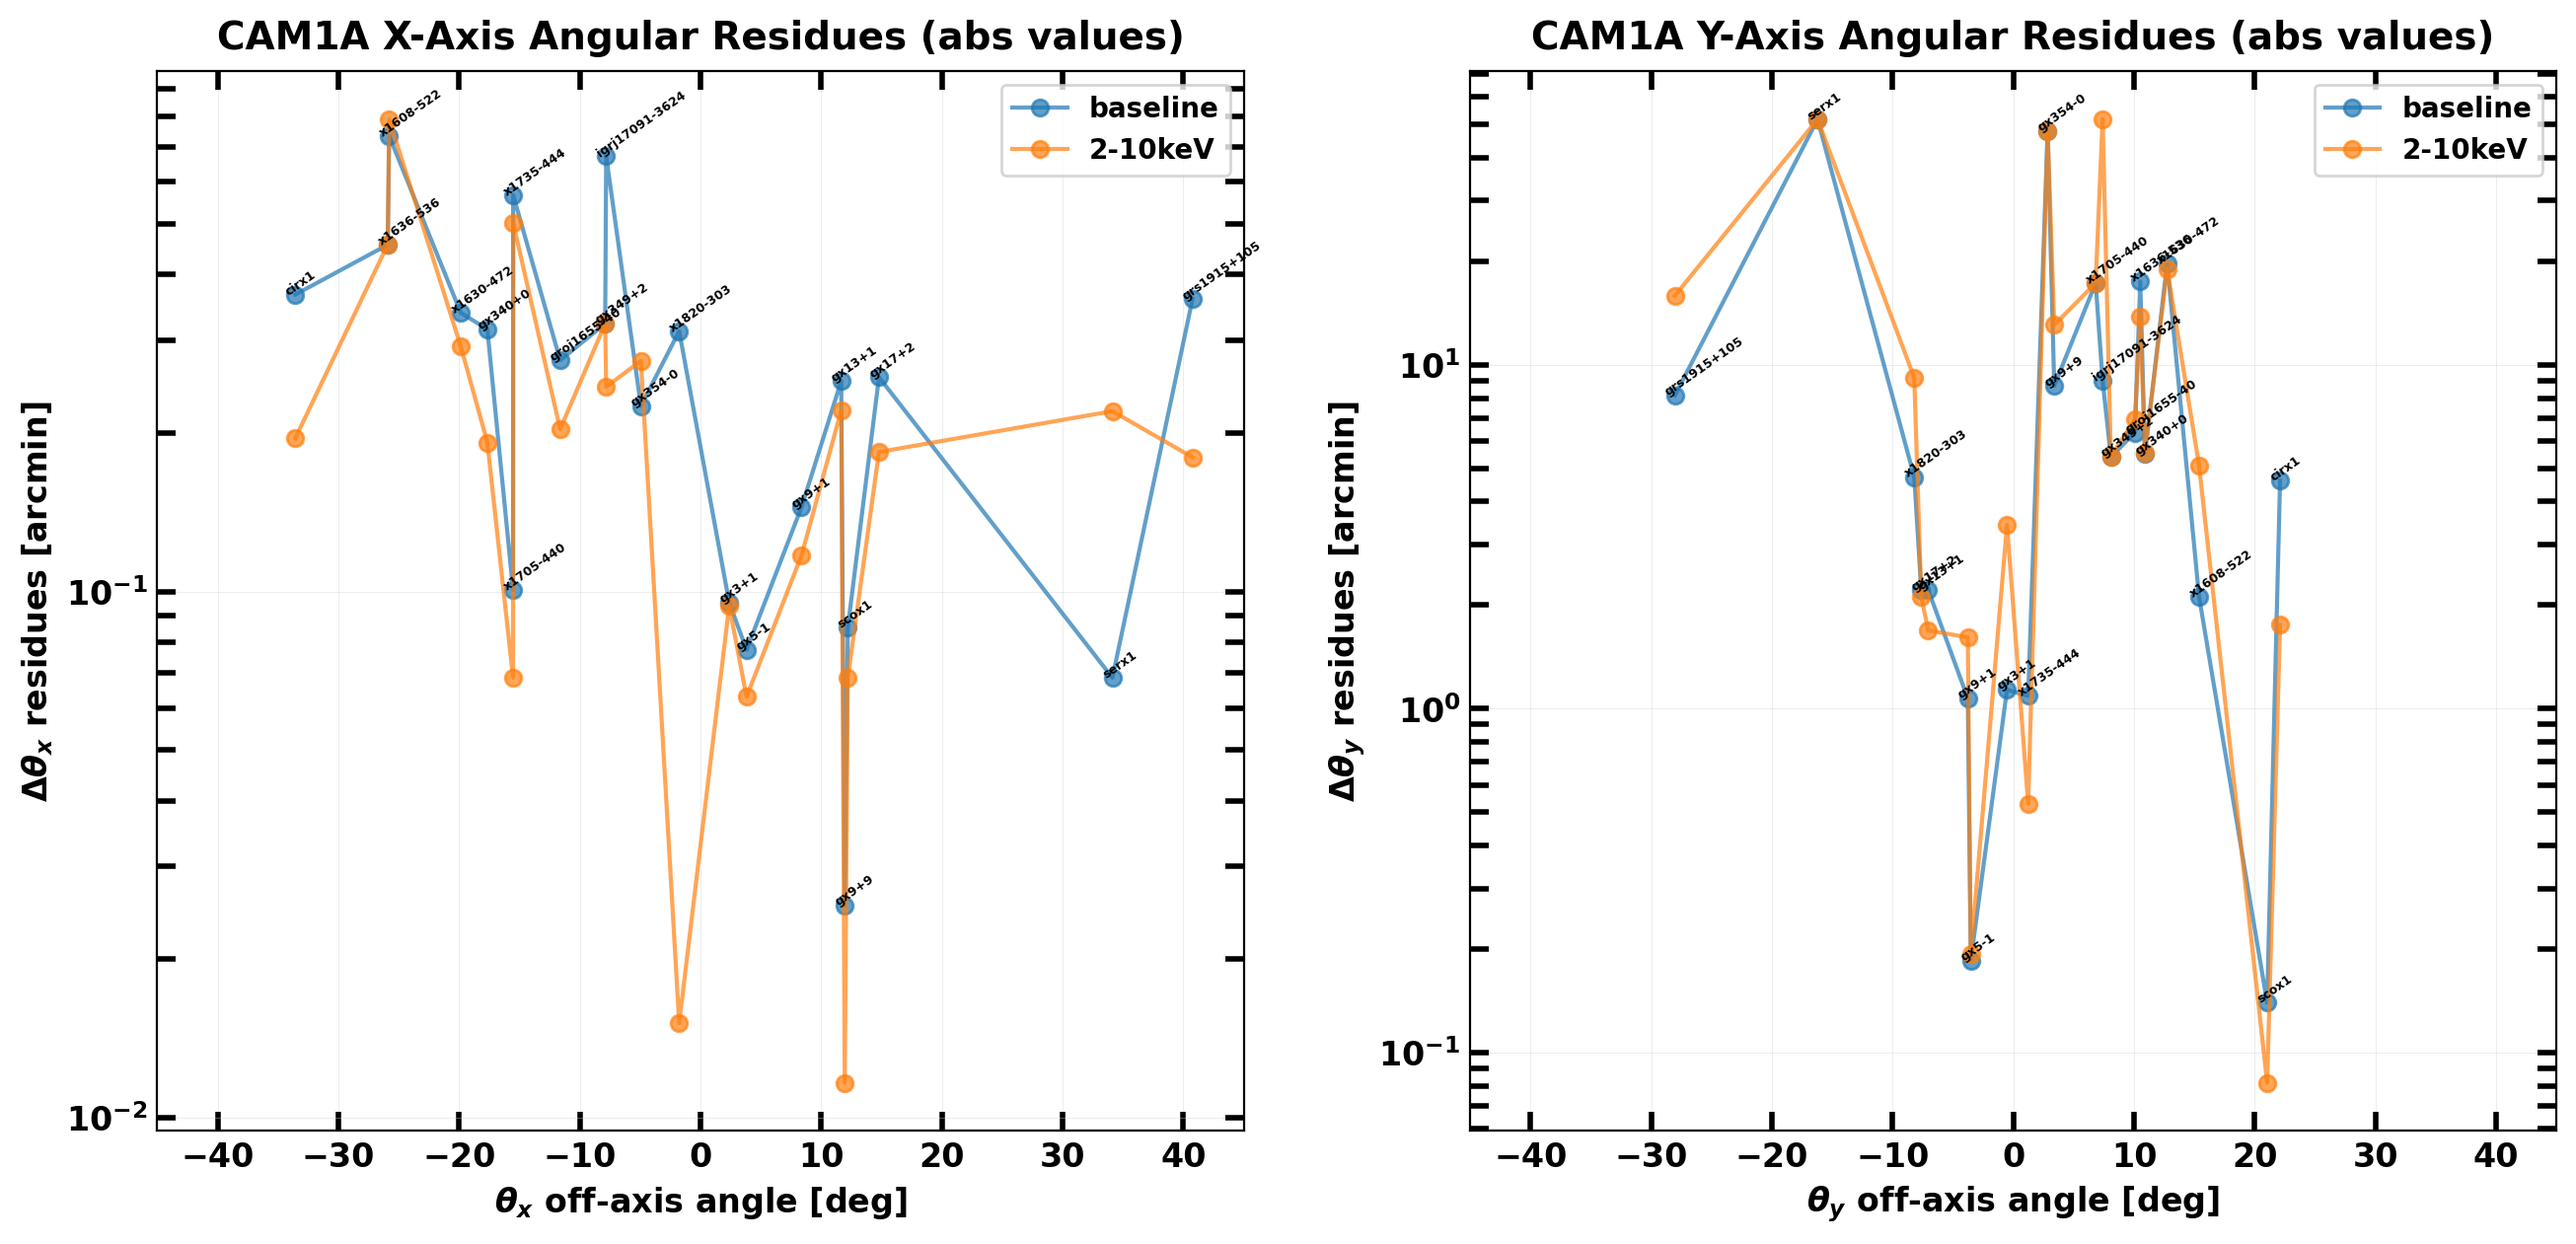

In [ ]:
def plot_resVSoffaxis(
    dfs: tuple[pd.DataFrame, ...],
    labels: tuple[str, ...],
    camID: str,
    show_IDs: bool = True,
    save_to: str | Path = None,
) -> None:
    """Plots the IROS runs angular coords residues vs the off-axis angle."""
    dfs_x = tuple(
        map(lambda x: extract_data_along_finedir(x).sort_values('theta_true_x'), dfs)
    )
    dfs_y = tuple(
        map(lambda y: extract_data_along_coarsedir(y).sort_values('theta_true_y'), dfs)
    )

    dsp = DSPlot(2, 1)
    alpha = 0.7

    fig, axs = dsp.config_subplots()
    for ax in axs:
        dsp.config_ticks(ax)
        dsp.config_axscale(ax, 'linear', 'log')

    #### add axis for camera fine direction
    dsp.config_labels(
        axs[0],
        f'{camID.upper()} X-Axis Angular Residues (abs values)',
        '$\\theta_{{x}}$ off-axis angle [deg]',
        '$\\Delta\\theta_{{x}}$ residues [arcmin]',
    )
    for df_x, xlabel in zip(dfs_x, labels):
        axs[0].plot(df_x['theta_true_x'], df_x['theta_res_x'], 'o-', alpha=alpha, label=xlabel)
    
    if (len(dfs) < 3) and show_IDs:
        for (_name, _x, _y) in zip(dfs_x[0]['ID'], dfs_x[0]['theta_true_x'], dfs_x[0]['theta_res_x']):
            axs[0].text(
                _x - 1, _y, _name, color='black',fontsize=0.75*6, fontweight='bold', rotation=35,
            )
    dsp.config_axlim(axs[0], (-45, 45), (None, None))
    axs[0].legend(loc='best')

    #### add axis for camera coarse direction
    dsp.config_labels(
        axs[1],
        f'{camID.upper()} Y-Axis Angular Residues (abs values)',
        '$\\theta_{{y}}$ off-axis angle [deg]',
        '$\\Delta\\theta_{{y}}$ residues [arcmin]',
    )
    for df_y, ylabel in zip(dfs_y, labels):
        axs[1].plot(df_y['theta_true_y'], df_y['theta_res_y'], 'o-', alpha=alpha, label=ylabel)
    
    if (len(dfs) < 3) and show_IDs:
        for (_name, _x, _y) in zip(dfs_y[0]['ID'], dfs_y[0]['theta_true_y'], dfs_y[0]['theta_res_y']):
            axs[1].text(
                _x - 1, _y, _name, color='black',fontsize=0.75*6, fontweight='bold', rotation=35,
            )
    dsp.config_axlim(axs[1], (-45, 45), (None, None))
    axs[1].legend(loc='best')

    if save_to is not None: fig.savefig(save_to)
    plt.show()


plot_resVSoffaxis(
    dfs=(dfs_camA[0], dfs_camA[1], dfs_camA[2]),
    labels=('baseline', '+10um', '2-10keV'),
    camID=ID_CAMERA_A,
    save_to=(
        savefig_to(SAVE_TO, f'angRes_vs_offAxis_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)
plot_resVSoffaxis(
    dfs=(dfs_camA[0], dfs_camA[1]),
    labels=('baseline', '+10um'),
    camID=ID_CAMERA_A,
    save_to=(
        savefig_to(SAVE_TO, f'angRes_vs_offAxis_bs_10um_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)
plot_resVSoffaxis(
    dfs=(dfs_camA[0], dfs_camA[2]),
    labels=('baseline', '2-10keV'),
    camID=ID_CAMERA_A,
    save_to=(
        savefig_to(SAVE_TO, f'angRes_vs_offAxis_bs_2-10keV_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

<br>

<br>

<br>

**Residues benchmark plots - Camera B**

In [12]:
dfs_camB = tuple(
    map(lambda x: build_run_DF(x, catalogueB, sdlB, wfm), logs_camB)
)

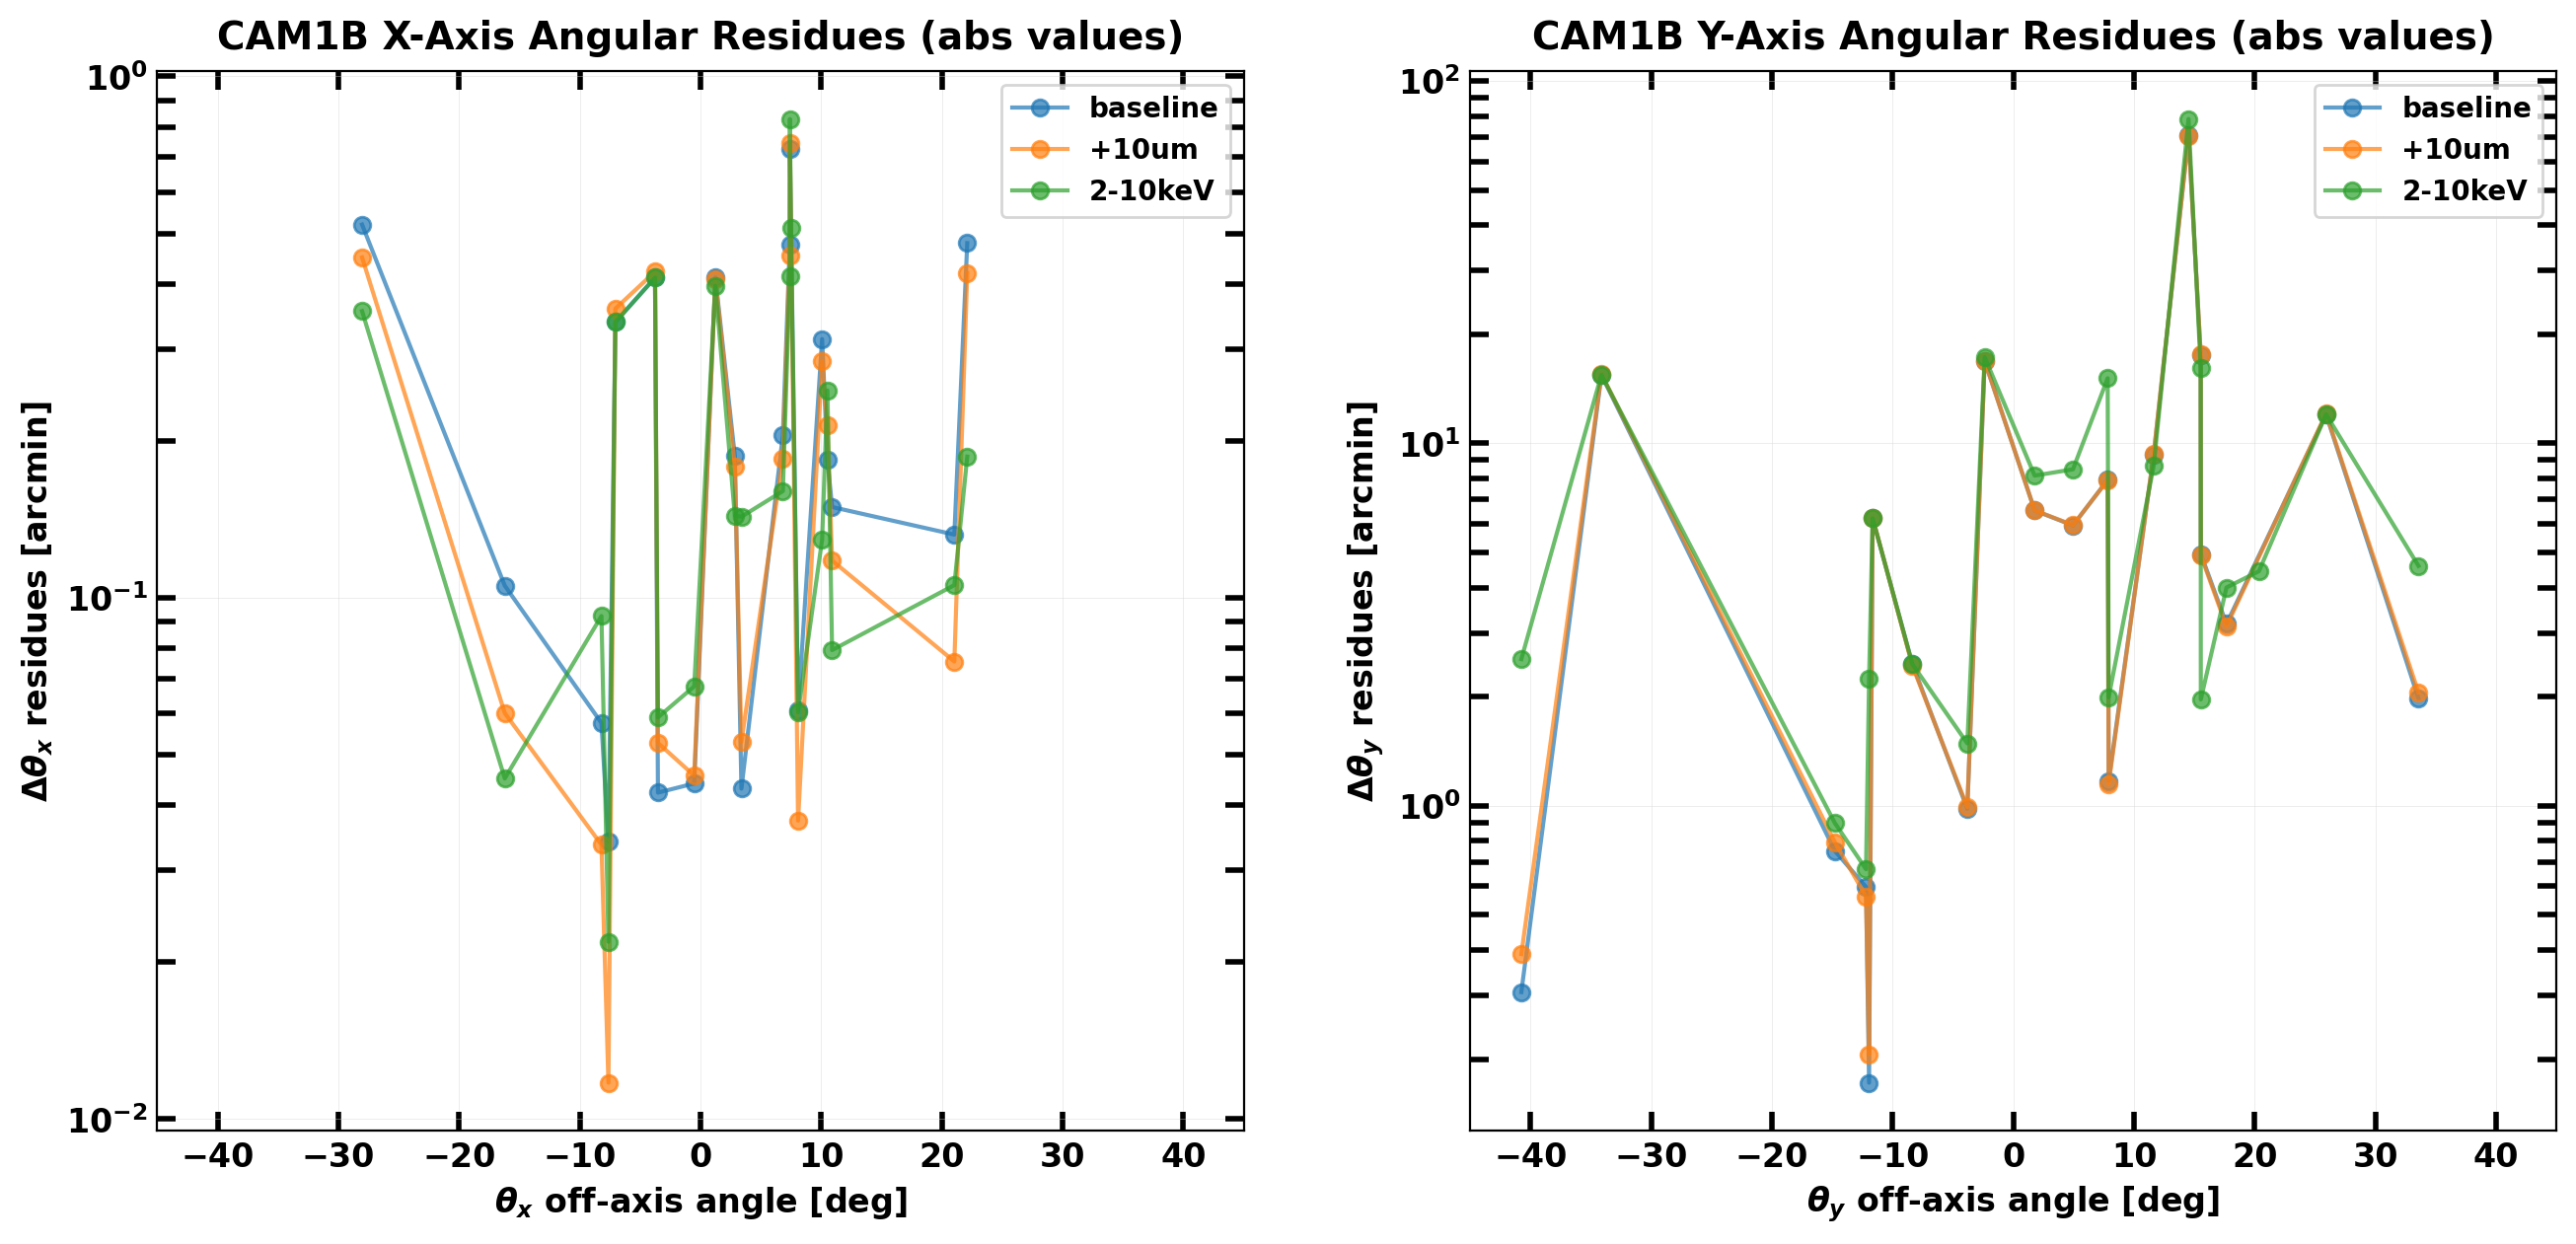

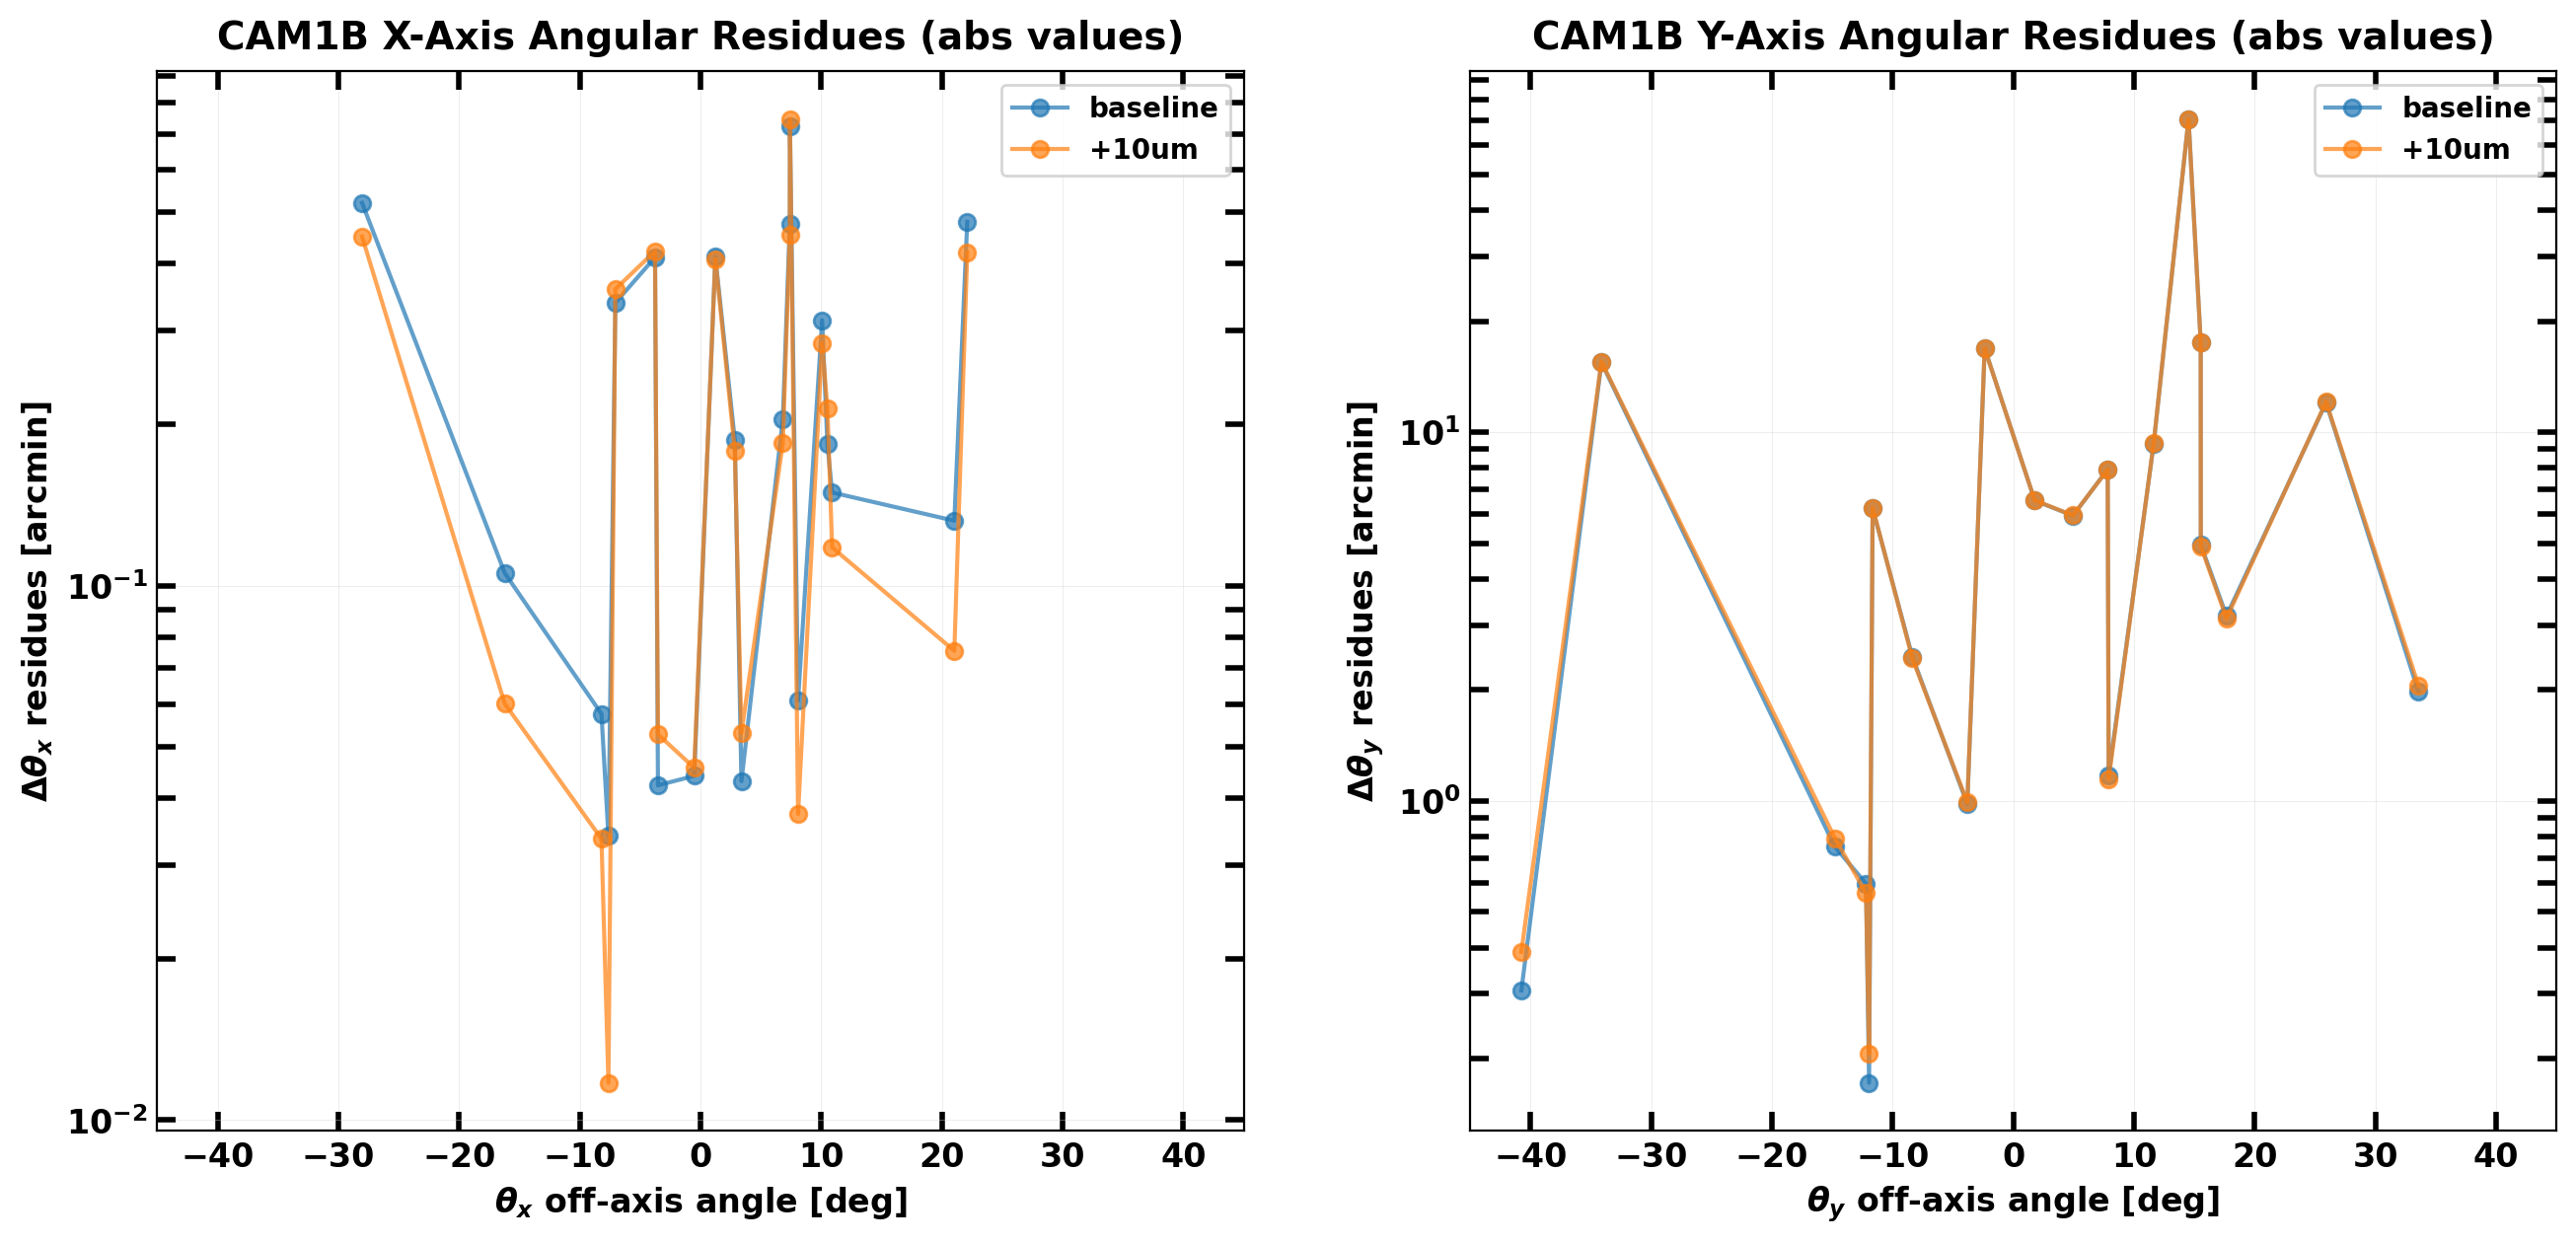

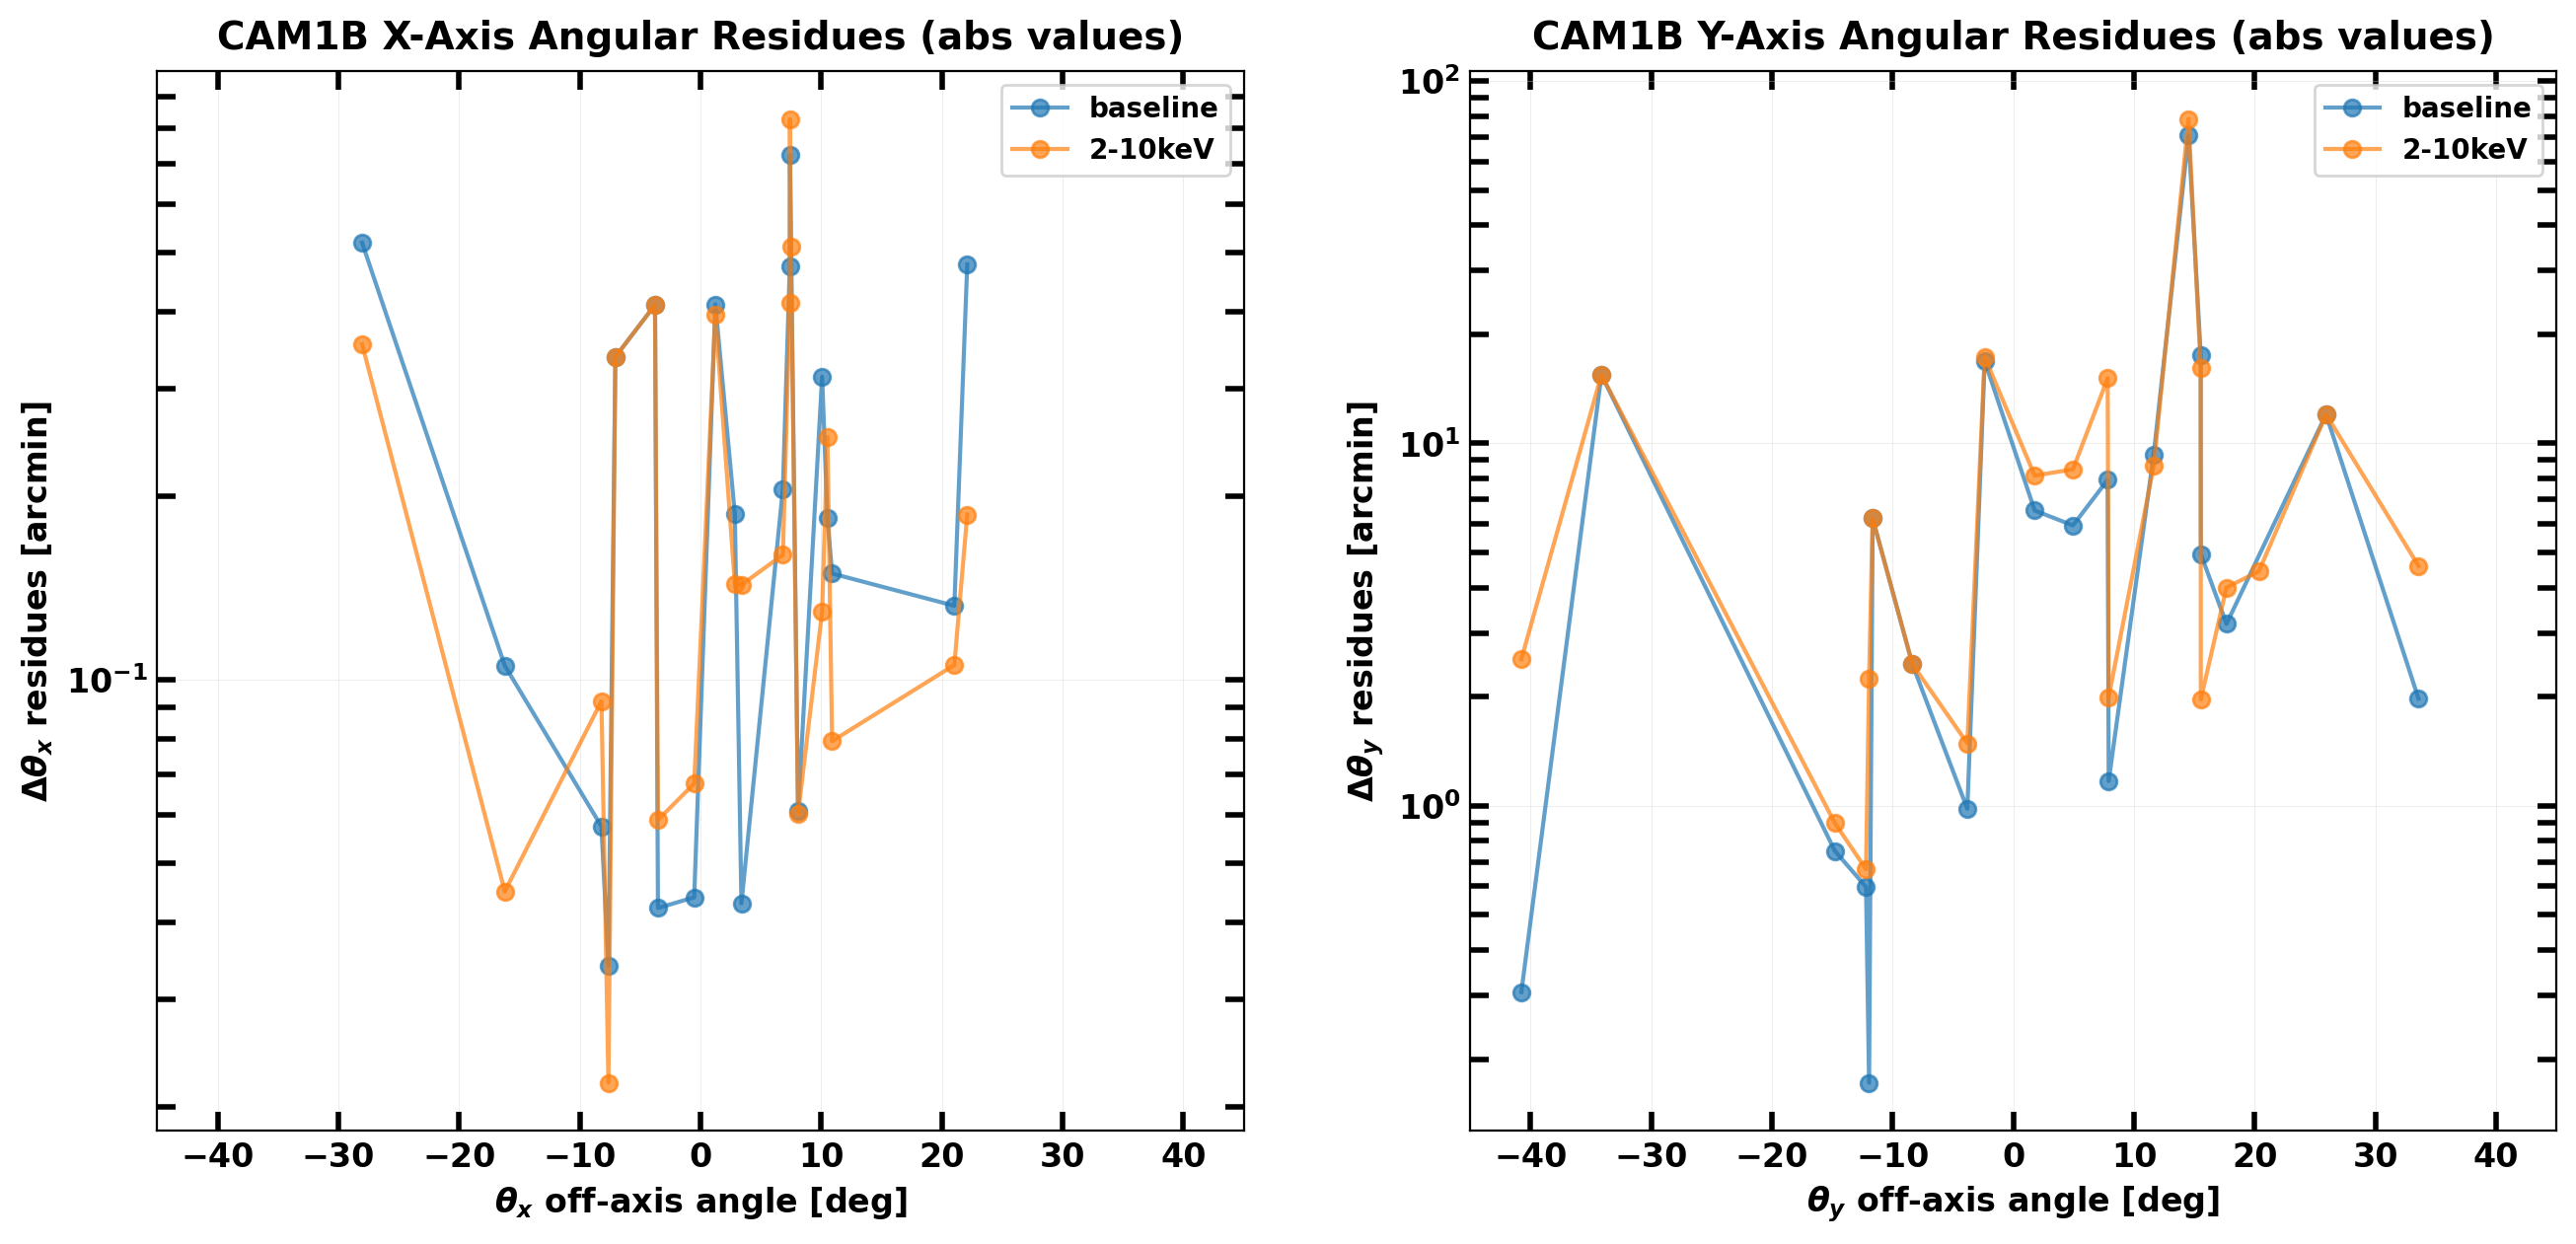

In [13]:
plot_resVSoffaxis(
    dfs=(dfs_camB[0], dfs_camB[1], dfs_camB[2]),
    labels=('baseline', '+10um', '2-10keV'),
    camID=ID_CAMERA_B,
    save_to=(
        savefig_to(SAVE_TO, f'angRes_vs_offAxis_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)
plot_resVSoffaxis(
    dfs=(dfs_camB[0], dfs_camB[1]),
    labels=('baseline', '+10um'),
    camID=ID_CAMERA_B,
    show_IDs=False,
    save_to=(
        savefig_to(SAVE_TO, f'angRes_vs_offAxis__bs_10um_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)
plot_resVSoffaxis(
    dfs=(dfs_camB[0], dfs_camB[2]),
    labels=('baseline', '2-10keV'),
    camID=ID_CAMERA_B,
    show_IDs=False,
    save_to=(
        savefig_to(SAVE_TO, f'angRes_vs_offAxis__bs_2-10keV_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)